#  Import packages

This code was coauthored with Gemini Flash Extended 3.6. Any code generation or debugging suggestions were explicitly reviewed, added to the document, updated with more explicit comments and notes, and validated by Daniel Kunk.

In [1]:
import h5py
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Prototyping

First, we set the file paths.

Second, we load the bounding boxes.

Third, we load the sleap data.

Finally, we do the spatial assignment based on the bounding boxes.

In [2]:
# 1. set paths for the SLEAP HDF5 and the ROItool JSON file
# Adjust these to point to a valid raw data file and its corresponding ROItool JSON containing the ROI coordinates
h5_path = "../../RpadiSleapInferencePipeline_Output/LD-Diet/agesync_7-29-25-rep1/LD-diet_agesync_7-29-25-rep1_Camera0_20250804_122315_0-215999_sleap.h5" 
json_path = "../ROItools/LD-diet_agesync_7-29-25-rep1_Camera0_20250804_122315_0-215999.json"

# 2. Load Bounding Boxes
with open(json_path, 'r') as f:
    roi_data = json.load(f)
boxes = roi_data['boxes'] # [cite: 19]

>NOTE:
>Since our H5 datasets aren't output from sleap, rather we generated them by converting a sleap generated CSV to H5 using pandas, they will be easier to read and aren't nested. 
>Here we can use pandas to read the H5 data and show that the data is just a pd dataframe.
>We can also show the first 20 columns in a list. and additionally, we can head this to see the full dimensions.

In [3]:
import pandas as pd

# Let Pandas do the heavy lifting of parsing the blocks
df = pd.read_hdf(h5_path, key='sleap_data')

# Check the shape to confirm it loaded correctly
print(f"DataFrame Shape: {df.shape}")

# Print the first 20 column names to see how SLEAP named the nodes and tracks
print("\nFirst 20 Columns:")
print(df.columns.tolist()[:20])

# Preview the actual data
display(df.head())

DataFrame Shape: (216000, 181)

First 20 Columns:
['frame_idx', 'inst0.track', 'inst0.track_score', 'inst0.score', 'inst0.ab.x', 'inst0.ab.y', 'inst0.ab.score', 'inst0.hd.x', 'inst0.hd.y', 'inst0.hd.score', 'inst0.cd.x', 'inst0.cd.y', 'inst0.cd.score', 'inst0.tarL1.x', 'inst0.tarL1.y', 'inst0.tarL1.score', 'inst0.tarL2.x', 'inst0.tarL2.y', 'inst0.tarL2.score', 'inst0.tarL3.x']


,frame_idx,inst0.track,inst0.track_score,inst0.score,inst0.ab.x,inst0.ab.y,inst0.ab.score,inst0.hd.x,inst0.hd.y,inst0.hd.score,...,inst5.tarL3.score,inst5.tarR1.x,inst5.tarR1.y,inst5.tarR1.score,inst5.tarR2.x,inst5.tarR2.y,inst5.tarR2.score,inst5.tarR3.x,inst5.tarR3.y,inst5.tarR3.score
0,0,NaN,NaN,1.001953,880.0,280.0,0.997876,864.0,256.0,0.861318,...,0.917186,1164.0,1352.0,0.464711,1156.0,1308.0,0.835930,1176.0,1292.0,0.962011
1,1,NaN,NaN,1.000977,880.0,280.0,1.000545,864.0,256.0,0.866523,...,0.898933,1164.0,1352.0,0.451860,1156.0,1308.0,0.858104,1176.0,1292.0,0.958885
2,2,NaN,NaN,1.000977,880.0,280.0,1.002974,864.0,256.0,0.865563,...,0.898995,1164.0,1352.0,0.450704,1156.0,1308.0,0.862618,1176.0,1292.0,0.958688
3,3,NaN,NaN,1.000977,880.0,280.0,1.000973,864.0,256.0,0.868928,...,0.907094,1164.0,1352.0,0.454736,1156.0,1308.0,0.855040,1176.0,1292.0,0.959163
4,4,NaN,NaN,1.000977,880.0,280.0,0.999847,864.0,256.0,0.867842,...,0.905215,1164.0,1352.0,0.453297,1156.0,1308.0,0.849257,1176.0,1292.0,0.961981


Now that we have both the json ROI coordinates and the sleap data H5 visualized and imported we can thus develop some code to assign individuals based on the ROI, 

Applying spatial bounding boxes... this might take a few seconds.


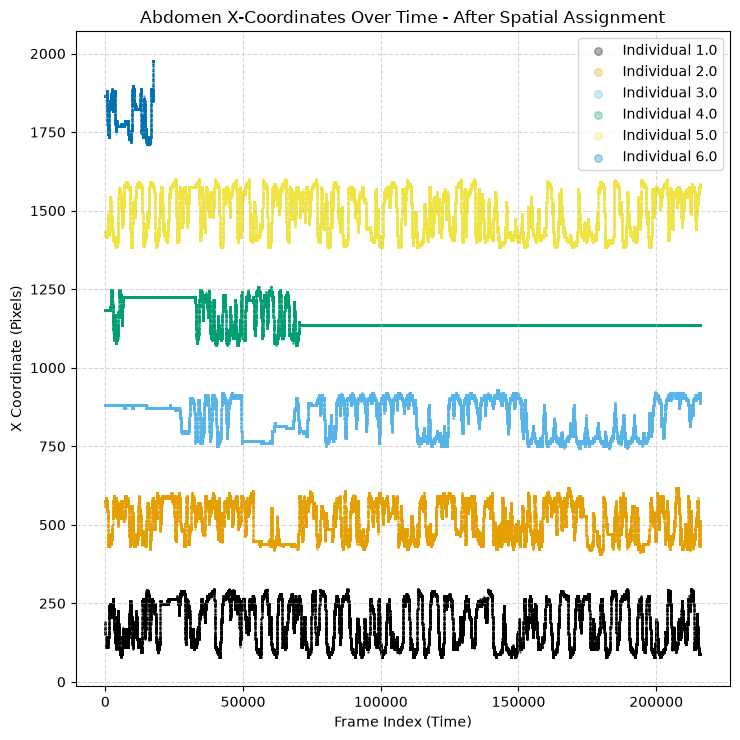

,frame_idx,x,y,individual
0,0,880.0,280.0,3.0
1,1,880.0,280.0,3.0
2,2,880.0,280.0,3.0
3,3,880.0,280.0,3.0
4,4,880.0,280.0,3.0


In [4]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt

# 1. Isolate Abdomen Data
# Find all columns related to the abdomen x/y coordinates, plus the frame index
ab_cols = ['frame_idx'] + [col for col in df.columns if '.ab.x' in col or '.ab.y' in col]
df_ab = df[ab_cols].copy()

# 2. Reshape from Wide to Long
# We will loop through the 6 instances (0-5) and stack them vertically
long_data = []
for i in range(6):
    # Extract data for just this instance
    temp = df_ab[['frame_idx', f'inst{i}.ab.x', f'inst{i}.ab.y']].copy()
    
    # Standardize column names so they stack neatly
    temp.columns = ['frame_idx', 'x', 'y']
    
    # Drop rows where this specific instance wasn't detected (NaNs)
    temp = temp.dropna(subset=['x', 'y'])
    long_data.append(temp)

# Combine all instances into one master dataframe
df_long = pd.concat(long_data, ignore_index=True)

# 3. Apply Spatial Assignment
# Making the assignment function
def assign_chamber(x, y, boxes):
    """Checks which bounding box an x,y coordinate falls into."""
    if pd.isna(x) or pd.isna(y):
        return np.nan
        
    for box in boxes:
        if (box['x_min'] <= x <= box['x_max']) and (box['y_min'] <= y <= box['y_max']):
            return box['label'] 
    return np.nan # Returns NA if it falls outside all boxes

# We map the function to assign the chamber based on (x, y)
print("Applying spatial bounding boxes... this might take a few seconds.")
df_long['individual'] = df_long.apply(lambda row: assign_chamber(row['x'], row['y'], boxes), axis=1)

# Drop any detections that fell completely outside the designated JSON bounding boxes
df_long = df_long.dropna(subset=['individual'])

# 4. Verify things look ok with a plot of the x-coordinates over time, colored by individual. Should be no overlaps.
plt.figure(figsize=(7.5, 7.5))

# Plot each individual with a distinct color
colors = plt.get_cmap('okabe_ito')  # A colorblind-friendly palette

for individual in sorted(df_long['individual'].unique()):
    subset = df_long[df_long['individual'] == individual]
    plt.scatter(subset['frame_idx'], subset['x'], 
                s=0.5, alpha=0.3, label=f'Individual {individual}', 
                color=colors(int(individual)-1))

plt.title('Abdomen X-Coordinates Over Time - After Spatial Assignment')
plt.xlabel('Frame Index (Time)')
plt.ylabel('X Coordinate (Pixels)')
# Make the legend points much bigger so they are clearly visible
legend = plt.legend(loc='upper right', markerscale=10.0, frameon=True)
for handle in legend.legend_handles:
    handle.set_sizes([30.0])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Preview the final, clean structure meant for parquet
display(df_long.head())

We can also generate a new plot that is more of an intuitive top down view of the arena. It also shows how the aphids move in X-Y space and if any escape their chambers.

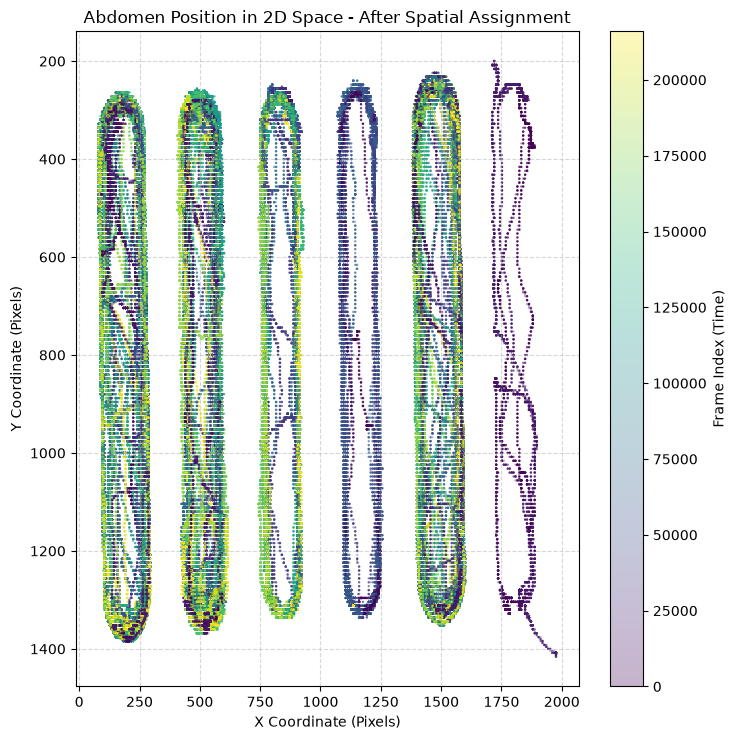

,frame_idx,x,y,individual
0,0,880.0,280.0,3.0
1,1,880.0,280.0,3.0
2,2,880.0,280.0,3.0
3,3,880.0,280.0,3.0
4,4,880.0,280.0,3.0


In [5]:
# 4. more visual Verification (2D Spatial Plot with Time as Color)
plt.figure(figsize=(7.5, 7.5))

# Plot all coordinates in X/Y space. 
# 'c' maps the color to the frame index, and 'viridis' is colorblind safe.
scatter = plt.scatter(df_long['x'], df_long['y'], 
                      c=df_long['frame_idx'], 
                      cmap='viridis', 
                      s=0.5, 
                      alpha=0.3)

# Add a colorbar to represent the timeline
cbar = plt.colorbar(scatter)
cbar.set_label('Frame Index (Time)')

# Invert the Y-axis so it matches standard video/image pixel coordinates 
# (where Y=0 is the top of the frame)
plt.gca().invert_yaxis()

plt.title('Abdomen Position in 2D Space - After Spatial Assignment')
plt.xlabel('X Coordinate (Pixels)')
plt.ylabel('Y Coordinate (Pixels)')

# Add gridlines to help visualize the spatial boundaries
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Preview the final, clean structure meant for parquet
display(df_long.head())

This is great. We can assign ID relatively easy as we did some months ago in R. 

We also probably want to make a plot in the same vein showing how this looks before we do any spatial ID assignment.

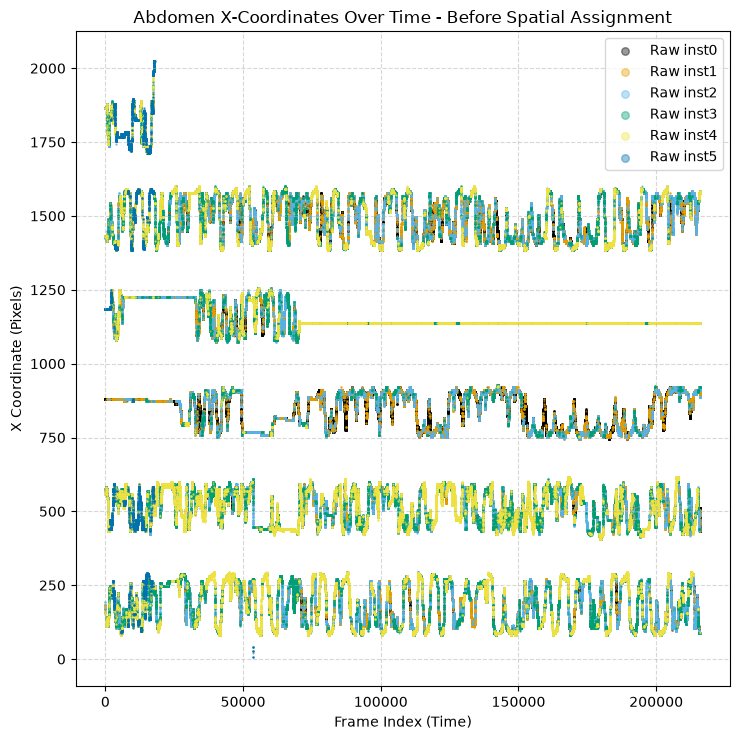

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate Abdomen Data
ab_cols = ['frame_idx'] + [col for col in df.columns if '.ab.x' in col or '.ab.y' in col]
df_ab = df[ab_cols].copy()

# 2. Reshape from Wide to Long (Raw Data before spatial assignment)
long_data = []
for i in range(6):
    temp = df_ab[['frame_idx', f'inst{i}.ab.x', f'inst{i}.ab.y']].copy()
    temp.columns = ['frame_idx', 'x', 'y']
    temp['instance'] = f'inst{i}'  # Track raw SLEAP instance ID
    temp = temp.dropna(subset=['x', 'y'])
    long_data.append(temp)

df_raw_long = pd.concat(long_data, ignore_index=True)

# 3. Plot Raw X-Coordinates Over Time Colored by Raw SLEAP Instance ID
plt.figure(figsize=(7.5, 7.5))
colors = plt.get_cmap('okabe_ito')  # A colorblind-friendly palette

for i, inst in enumerate(df_raw_long['instance'].unique()):
    subset = df_raw_long[df_raw_long['instance'] == inst]
    plt.scatter(subset['frame_idx'], subset['x'], 
                s=0.5, alpha=0.4, label=f'Raw {inst}', 
                color=colors(i))

plt.title('Abdomen X-Coordinates Over Time - Before Spatial Assignment')
plt.xlabel('Frame Index (Time)')
plt.ylabel('X Coordinate (Pixels)')

# Make the legend points much bigger so they are clearly visible
legend = plt.legend(loc='upper right', markerscale=10.0, frameon=True)
for handle in legend.legend_handles:
    handle.set_sizes([30.0])

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Prototyping H5 to Parquet across multiple H5 files from the same rep... 
We have a good idea of how assigning IDs will work. But now we want to prototype the conversion to parquet database files. We can try this with 5 or so files to see how it would work. We typically would want to do this across all 96 files but we will try it with a test set of 5 h5 files first to see how it works out, the output parquet/arrow file size, etc.

In [ ]:
import os
import glob
import re
import json
from pathlib import Path
import pandas as pd
import numpy as np

# 1. Define the Wrapper Function
def process_video_to_df(h5_path, boxes):
    """Parses a single H5 file, assigns IDs based on pre-loaded boxes, and injects metadata."""
    
    # 1a. Load SLEAP Data
    df = pd.read_hdf(h5_path, key='sleap_data') # the key is `sleap_data` and can be verified by inspecting the HDF5 input files... A bit different than the true sleap export since we generated this from a temp csv from sleapio.
    
    # 1b. Isolate and Reshape Abdomen Data
    ab_cols = ['frame_idx'] + [col for col in df.columns if '.ab.x' in col or '.ab.y' in col] # `frame_idx` and `.ab.x`/`.ab.y` are columns in our OG h5 file.
    # new df with ab data and frames. TODO: copy over the abdomen prediction accuracy as well?
    df_ab = df[ab_cols].copy()
    
    # Dynamically identify all instances SLEAP detected in this specific video only. Updated from previous approach which would fail if fewer/more instances were detected after the first video, i.e. if an aphid escapes, etc..
    # This looks at the column names and pulls out unique prefixes (e.g., 'inst0', 'inst1', up to 'inst5' which is the max we expect for our 6 aphids).
    instances = set([col.split('.')[0] for col in df_ab.columns if col.startswith('inst')])

    # create an empty list named long data
    long_data = []
    # start a for loop to iterate through each instance and reshape the data
    for inst in instances:
        x_col = f'{inst}.ab.x'
        y_col = f'{inst}.ab.y'
        
        # Safely check if the abdomen coordinates actually exist for this instance
        if x_col in df_ab.columns and y_col in df_ab.columns:
            temp = df_ab[['frame_idx', x_col, y_col]].copy()
            temp.columns = ['frame_idx', 'x', 'y']
            temp = temp.dropna(subset=['x', 'y'])
            long_data.append(temp)
            
    df_long = pd.concat(long_data, ignore_index=True)
    
    # 1c. Apply Spatial Assignment
    def assign_chamber(x, y, boxes):
        if pd.isna(x) or pd.isna(y):
            return np.nan
        for box in boxes:
            if (box['x_min'] <= x <= box['x_max']) and (box['y_min'] <= y <= box['y_max']):
                return box['label'] 
        return np.nan 
        
    df_long['individual'] = df_long.apply(lambda row: assign_chamber(row['x'], row['y'], boxes), axis=1)
    df_long = df_long.dropna(subset=['individual'])
    df_long['individual'] = df_long['individual'].astype(int)
    
    # 1d. Inject Metadata Robustly
    filename = Path(h5_path).stem
    df_long['video_id'] = filename
    
    if 'LD' in filename.upper():
        df_long['treatment'] = 'LD-diet'
    elif 'DD' in filename.upper():
        df_long['treatment'] = 'DD-diet'
    else:
        df_long['treatment'] = 'Unknown'
        
    rep_match = re.search(r'(rep\d+)', filename, re.IGNORECASE)
    df_long['replicate'] = rep_match.group(1).lower() if rep_match else 'unknown'
    
    return df_long

# 2. Run the Batch Test with file paths and globs 

# Paths for the test
test_dir = "../../RpadiSleapInferencePipeline_Output/LD-Diet/agesync_7-29-25-rep1/"
h5_files = glob.glob(os.path.join(test_dir, "*.h5"))[:5] 

# Define the single JSON file for this entire replicate, update once delpoying for snakemake, hardcode ROI json to rep inside config.
json_file = "../ROItools/LD-diet_agesync_7-29-25-rep1_Camera0_20250804_122315_0-215999.json"

# Load the boxes ONCE before the loop
with open(json_file, 'r') as f:
    roi_data = json.load(f)
global_boxes = roi_data['boxes']

all_processed_dfs = []

print(f"Starting batch process for {len(h5_files)} files using 1 master ROI file...")

for h5_file in h5_files:
    print(f"Processing: {Path(h5_file).name}")
    # Pass the pre-loaded global_boxes into the function
    processed_df = process_video_to_df(h5_file, global_boxes)
    all_processed_dfs.append(processed_df)

# 3. Concatenate and Export
if all_processed_dfs:
    master_df = pd.concat(all_processed_dfs, ignore_index=True)
    
    # Explicitly cast metadata columns to standard strings to appease PyArrow
    master_df['video_id'] = master_df['video_id'].astype(str)
    master_df['treatment'] = master_df['treatment'].astype(str)
    master_df['replicate'] = master_df['replicate'].astype(str)
    
    print("\n--- Final Master DataFrame Shape ---")
    print(master_df.shape)
    display(master_df.head())
    
    # Set index=False to prevent serialization errors of the DataFrame index
    output_parquet = "test_batch_5_videos.parquet"
    master_df.to_parquet(
        output_parquet, 
        engine='pyarrow', 
        compression='snappy', 
        index=False
    )
    
    file_size_mb = os.path.getsize(output_parquet) / (1024 * 1024)
    print(f"\nSuccessfully wrote {output_parquet}")
    print(f"File Size: {file_size_mb:.2f} MB")

Starting batch process for 5 files using 1 master ROI file...
Processing: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_122315_0-215999_sleap.h5
Processing: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_132316_216000-431999_sleap.h5
Processing: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_142316_432000-647999_sleap.h5
Processing: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_152316_648000-863999_sleap.h5
Processing: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_162317_864000-1079999_sleap.h5

--- Final Master DataFrame Shape ---
(5360072, 7)


,frame_idx,x,y,individual,video_id,treatment,replicate
0,0,880.0,280.0,3,LD-diet_agesync_7-29-25-rep1_Camera0_20250804_...,LD-diet,rep1
1,1,880.0,280.0,3,LD-diet_agesync_7-29-25-rep1_Camera0_20250804_...,LD-diet,rep1
2,2,880.0,280.0,3,LD-diet_agesync_7-29-25-rep1_Camera0_20250804_...,LD-diet,rep1
3,3,880.0,280.0,3,LD-diet_agesync_7-29-25-rep1_Camera0_20250804_...,LD-diet,rep1
4,4,880.0,280.0,3,LD-diet_agesync_7-29-25-rep1_Camera0_20250804_...,LD-diet,rep1



Successfully wrote test_batch_5_videos.parquet
File Size: 28.06 MB


This is great. We saved a 28.06 MB parquet file. Looking at these input .H5 files they are all approximately 55-60,000 KB each which is approximately 50-60MB or 300MB total. 

With a pq file of only 28.06 for 5 videos thats about 5.6MB per H5 file. With all 96 files, the file should approximately half a gig ~500MB if it all scales linearly.

Additionally, this only took about 32 seconds. Scaling to 96 videos should only be about 10 minutes of compute.

>NOTE: These parquet files do not have a running frame count. Rather they contain the video ID and the frame ID for that video. The running frame ID can be computed downstream from the videoID and the frame_idx.
>Leaving this running frame column absent should save space as we don't need an int64 column.

=== Parquet Schema & Metadata Verification ===
Total Rows: 5,360,072
Memory Usage: 706.37 MB

Data Types:
frame_idx       int64
x             float64
y             float64
individual      int64
video_id          str
treatment         str
replicate         str
dtype: object

Unique Videos Included: 5
Unique Individuals Detected: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Verified Video Offsets:
Offset: 0  |  Video: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_122315_0-215999_sleap
Offset: 216,000  |  Video: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_132316_216000-431999_sleap
Offset: 432,000  |  Video: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_142316_432000-647999_sleap
Offset: 648,000  |  Video: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_152316_648000-863999_sleap
Offset: 864,000  |  Video: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_162317_864000-1079999_sleap


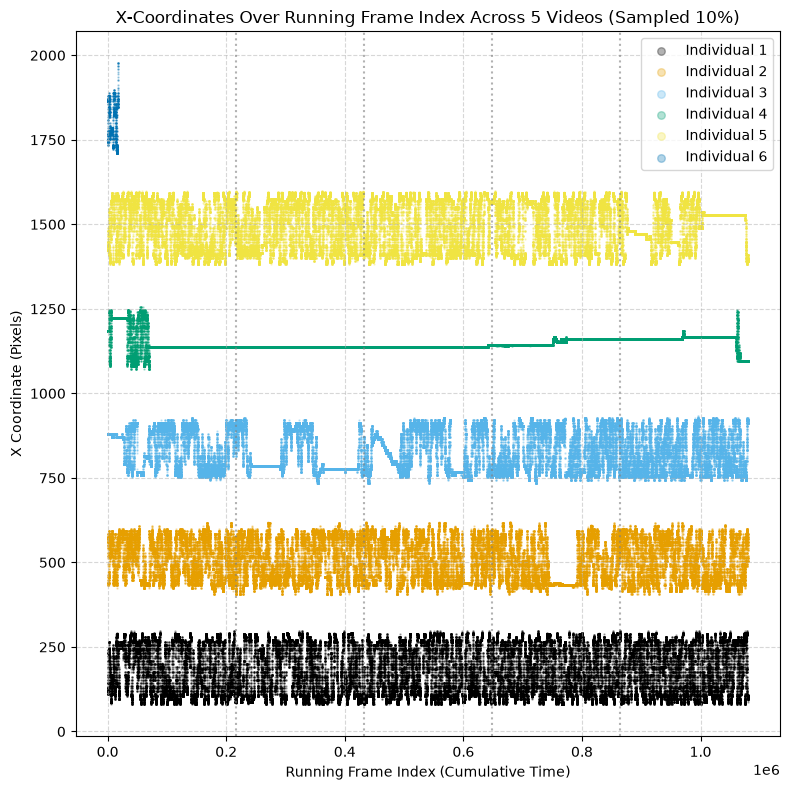

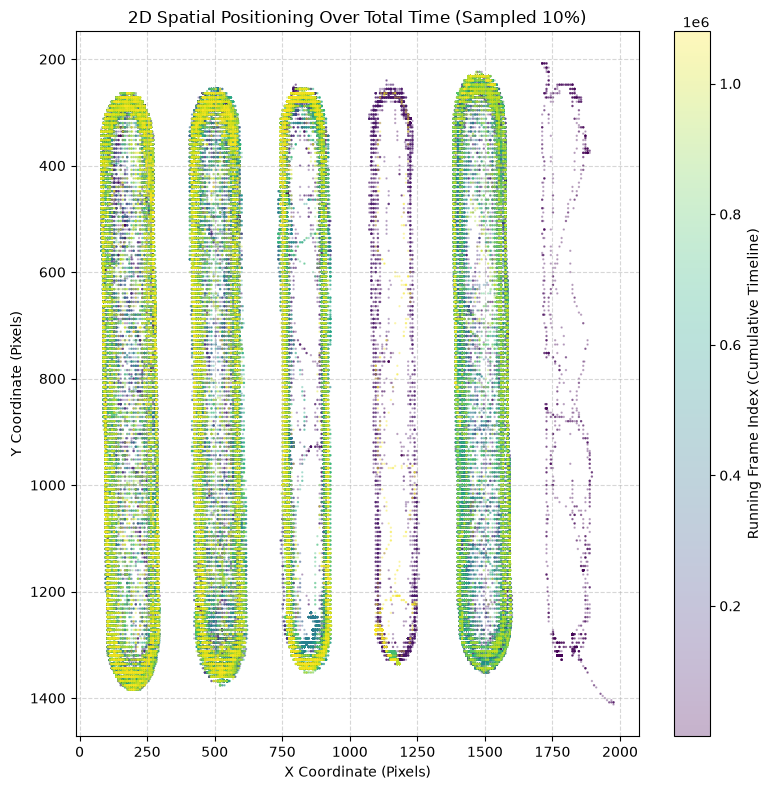

In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and Verify Parquet Data
parquet_path = "test_batch_5_videos.parquet"

# debug checks
if not os.path.exists(parquet_path):
    print(f"Error: Could not find {parquet_path}. Please make sure step 3 ran successfully.")
else:
    # Read the parquet file into a Pandas DataFrame and run some basic checks
    df_pq = pd.read_parquet(parquet_path, engine='pyarrow')
    
    print("=== Parquet Schema & Metadata Verification ===")
    print(f"Total Rows: {len(df_pq):,}")
    print(f"Memory Usage: {df_pq.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    print("\nData Types:")
    print(df_pq.dtypes)
    print("\nUnique Videos Included:", df_pq['video_id'].nunique())
    print("Unique Individuals Detected:", sorted(df_pq['individual'].unique()))

# fixed: Calculate Running Frame ID On-the-Fly
    # Extract the starting frame number from the very end of the video_id string
    def extract_start_frame(video_id):
        # Looks specifically for the frame range anchored at the end of the filename
        match = re.search(r'_(\d+)-\d+(?:_sleap)?$', str(video_id))
        return int(match.group(1)) if match else 0

    # Add video_start_frame offset to the local frame_idx
    video_offsets = {vid: extract_start_frame(vid) for vid in df_pq['video_id'].unique()}
    
    # Quick print to verify the offsets are working correctly before plotting!
    print("\nVerified Video Offsets:")
    for vid, offset in video_offsets.items():
        print(f"Offset: {offset:,}  |  Video: {vid}")
        
    df_pq['running_frame_idx'] = df_pq['frame_idx'] + df_pq['video_id'].map(video_offsets)

    # 2. Downsample for Visual Performance
    # Sort by running_frame_idx first, then take a 10% random sample
    sample_ratio = 0.1 
    df_sample = df_pq.sample(frac=sample_ratio, random_state=42).sort_values('running_frame_idx')

    #  Plot 1: X-Coordinates Over Continuous Running Frame Index
    plt.figure(figsize=(8, 8))
    colors = plt.get_cmap('okabe_ito')  # Colorblind-friendly palette

    for indiv in sorted(df_sample['individual'].unique()):
        subset = df_sample[df_sample['individual'] == indiv]
        plt.scatter(
            subset['running_frame_idx'], 
            subset['x'], 
            s=0.5, 
            alpha=0.3, 
            label=f'Individual {indiv}', 
            color=colors(indiv - 1)
        )

    plt.title(f'X-Coordinates Over Running Frame Index Across 5 Videos (Sampled {int(sample_ratio*100)}%)')
    plt.xlabel('Running Frame Index (Cumulative Time)')
    plt.ylabel('X Coordinate (Pixels)')

    # Add vertical dashed lines indicating video transition boundaries
    unique_start_frames = sorted(set(video_offsets.values()))[1:]
    for start_f in unique_start_frames:
        plt.axvline(x=start_f, color='gray', linestyle=':', alpha=0.6)

    # Enlarge legend markers for clarity
    legend = plt.legend(loc='upper right', markerscale=10.0, frameon=True)
    for handle in legend.legend_handles:
        handle.set_sizes([30.0])

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Plot 2: Top-Down 2D Spatial Arena Map Colored by Frame Color Gradient
    plt.figure(figsize=(8, 8))

    scatter = plt.scatter(
        df_sample['x'], 
        df_sample['y'], 
        c=df_sample['running_frame_idx'], 
        cmap='viridis',  # Colorblind-safe palette
        s=0.5, 
        alpha=0.3
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label('Running Frame Index (Cumulative Timeline)')

    # Invert Y-axis to match top-down camera perspective
    plt.gca().invert_yaxis()

    plt.title(f'2D Spatial Positioning Over Total Time (Sampled {int(sample_ratio*100)}%)')
    plt.xlabel('X Coordinate (Pixels)')
    plt.ylabel('Y Coordinate (Pixels)')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()